In [ ]:
!pip install split-folders

## Importações

In [ ]:
import kagglehub
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import shap
import splitfolders
from PIL import Image
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


## Baixando Dados do [Dataset](https://www.kaggle.com/datasets/troykueh/real-vs-fake-faces-stylegan3/data)

In [ ]:
DATASET_PATH = kagglehub.dataset_download("troykueh/real-vs-fake-faces-stylegan3")

print("Path to dataset files:", DATASET_PATH)

Using Colab cache for faster access to the 'real-vs-fake-faces-stylegan3' dataset.
Path to dataset files: /kaggle/input/real-vs-fake-faces-stylegan3


In [ ]:
csv_path=os.path.join(DATASET_PATH, 'metadata.csv')

df = pd.read_csv(csv_path)

df

,filepath,label
0,Fake faces/fake_9650.png,fake
1,Real faces/real_2041.png,real
2,Real faces/real_8668.png,real
3,Real faces/real_1114.png,real
4,Fake faces/fake_6902.png,fake
...,...,...
19995,Fake faces/fake_8284.png,fake
19996,Fake faces/fake_8964.png,fake
19997,Real faces/real_5390.png,real
19998,Real faces/real_860.png,real


In [ ]:
print('Balanceamento dos dados')
print(df['label'].value_counts(normalize=True))

Balanceamento dos dados
label
fake    0.5
real    0.5
Name: proportion, dtype: float64


## Pré Processamento de Dados

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 128

pasta_destino = "dataset_dividido"

if not os.path.exists(pasta_destino):
    splitfolders.ratio(
        DATASET_PATH,
        output=pasta_destino,
        seed=123,
        ratio=(0.70, 0.15, 0.15),
        group_prefix=None,
        move=False
    )
    print("Divisão concluída com sucesso!")

print("\nConjunto de Treino (70%):")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(pasta_destino, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

print("\nConjunto de Validação (15%):")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(pasta_destino, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("\nConjunto de Teste (15%):")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(pasta_destino, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

class_names = train_dataset.class_names
print(f"\nClasses identificadas: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Copying files: 20000 files [03:05, 107.64 files/s]


Divisão concluída com sucesso!

Conjunto de Treino (70%):
Found 14000 files belonging to 2 classes.

Conjunto de Validação (15%):
Found 3000 files belonging to 2 classes.

Conjunto de Teste (15%):
Found 3000 files belonging to 2 classes.

Classes identificadas: ['Fake faces', 'Real faces']


In [ ]:
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

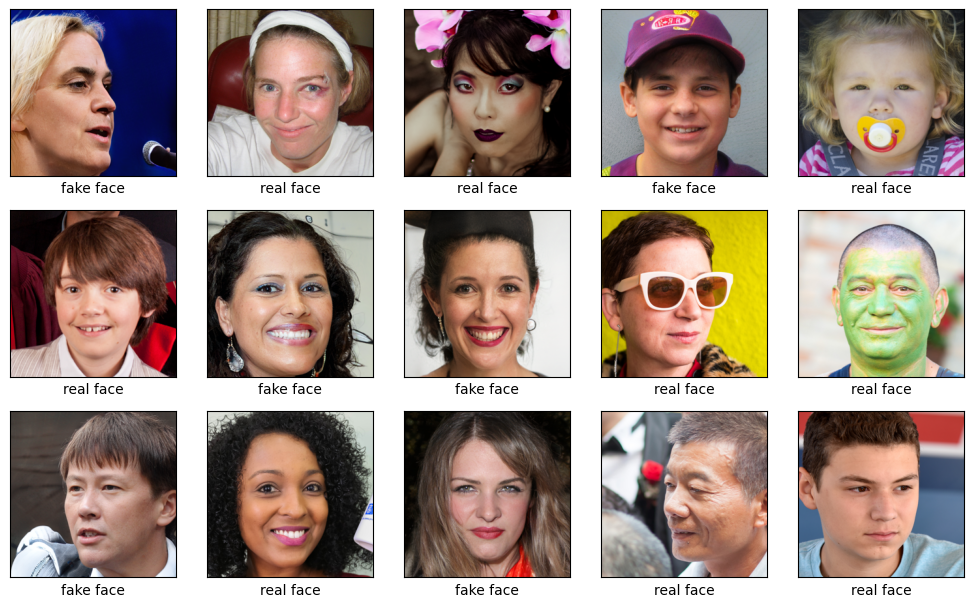

In [ ]:
class_names = ['fake face', 'real face']

plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(min(15, len(images))):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)
        label_idx = int(labels[i])
        plt.xlabel(class_names[label_idx])
plt.tight_layout()
plt.show()

## Treinamento
### modelo selecionado: EfficientNet

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.GaussianNoise(0.01),
])

In [ ]:
Efficientmodel = EfficientNetV2S(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

Efficientmodel.trainable = True

for layer in Efficientmodel.layers[:-30]:
    layer.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    Efficientmodel,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,511,969 (78.25 MB)

 Trainable params: 2,124,801 (8.11 MB)

 Non-trainable params: 18,387,168 (70.14 MB)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
)

checkpoint = ModelCheckpoint(
    filepath='deepfake_model_best.keras',
    monitor='val_accuracy',
    mode="max",
    save_best_only=True,
    verbose=1
)

In [ ]:
EPOCHS = 100

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.6877 - loss: 0.6131
Epoch 1: val_accuracy improved from None to 0.83533, saving model to deepfake_model_best.keras

Epoch 1: finished saving model to deepfake_model_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 147s 984ms/step - accuracy: 0.7421 - loss: 0.5515 - val_accuracy: 0.8353 - val_loss: 0.4028
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.8232 - loss: 0.4216
Epoch 2: val_accuracy improved from 0.83533 to 0.86567, saving model to deepfake_model_best.keras

Epoch 2: finished saving model to deepfake_model_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 132s 972ms/step - accuracy: 0.8329 - loss: 0.4056 - val_accuracy: 0.8657 - val_loss: 0.3420
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.8589 - loss: 0.3621
Epoch 3: val_accuracy improved from 0.86567 to 0.88067, saving model to deepfake_model_best.keras

Epoch 3: finished saving model to deepfake_model_best.keras
110/110 ━━━━━━━━━

In [ ]:
model.save('deepfake_model.keras')

## Métricas do modelo

In [ ]:
def load_best_model(model_path):
    model = tf.keras.models.load_model(model_path)
    return model

model = load_best_model('deepfake_model_best.keras')

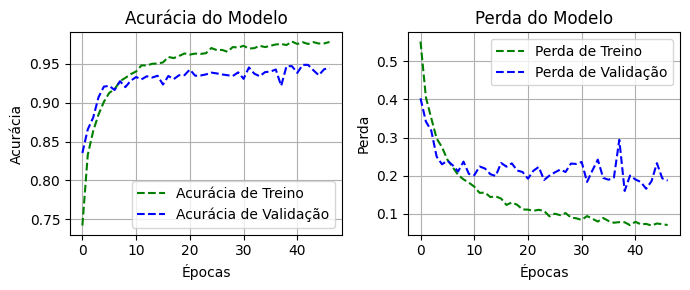

In [ ]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'g--', label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], 'b--', label='Acurácia de Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'g--', label='Perda de Treino')
plt.plot(history.history['val_loss'], 'b--', label='Perda de Validação')
plt.title('Perda do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob = model.predict(test_dataset)

y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = np.concatenate([y.numpy() for x, y in validation_dataset], axis=0).flatten()

relatorio = classification_report(y_true, y_pred, target_names=class_names)

print("Relatório de Classificação (Validation Dataset):")
print(relatorio)

24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 911ms/step
Relatório de Classificação (Validation Dataset):
              precision    recall  f1-score   support

   fake face       0.96      0.93      0.95      1500
   real face       0.93      0.96      0.95      1500

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000



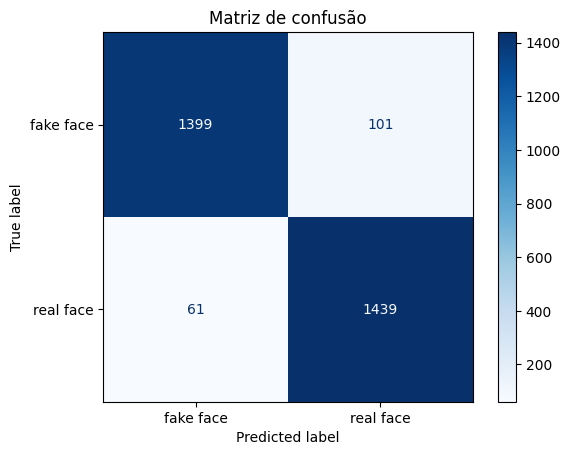

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cmd.plot(cmap='Blues')
plt.title('Matriz de confusão')
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()